# Figure 4: Reward Rate vs. Bound

Translation of `Figure04_RRvsBound.m`

## What this notebook does

Shows how participants' decision bounds relate to their reward rate (coins earned per step) across three blocks in the open-loop (OL) task.

**Top row (one panel per block)**: Scatter of mean bound (x) vs. reward rate (y) per subject. A simulation ribbon (5th–95th percentile of reward rate vs. bound from 100 simulated subjects) is overlaid in pink, with a dashed vertical line at the reward-rate-maximizing bound.

**Bottom row**: Scatter of mean bound in block 1 vs. block 2 (left), and block 2 vs. block 3 (right), testing whether bounds change systematically across blocks.

**Data**: Open-loop (OL) task, all three blocks, lowest SNR condition (SNR index 0).

## Imports

Imports standard scientific Python libraries and pigeon analysis functions. No data loading or filtering.

## Load data

Loads all OL (open-loop) trials via `get_data_table(task_type='OL')`. This reads all subject CSV files, computes bounds and DTs, marks wall hits, and applies bias correction if available.

## Compute bound and coin summaries

**`get_bound_summary`** (via `get_good_trial_array` internally):
- **Data included**: `DT ≥ 1`, `trial_number ≥ 10`, `bound` finite and non-zero, `correct ≥ 0`, `wall_hit = False`, `rt_below_cutoff = False`
- **Data excluded**: Short DT trials, warm-up trials, wall-hit trials, missing bounds
- Output: mean and std of |bound| per (subject, block, SNR) using `max_rt='all'` (no per-DT binning)

**Coin summary** (computed inline):
- For each (subject, block, SNR), takes the last `coin_count` value (cumulative total at end of block)
- Reward rate = total coins / 600 steps per block
- **Data included**: All trials sorted by trial number; last coin_count value per group
- **Data excluded**: Subjects/blocks/SNRs with no valid trials

In [ ]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

from pigeon.data import get_data_table
from pigeon.stats import get_bound_summary
from pigeon.simulate import get_simulated_data_table
from pigeon.pathDefaults import FIGURES_DIR

In [2]:
data_table_ol = get_data_table(task_type='OL')

  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_14h39.24.096.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_15h37.48.260.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h34.46.761.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h35.25.285.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.33.669.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.41.364.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.49.086.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

In [3]:
BLOCKS    = [1, 2, 3]
SNR_INDEX = 0  # first (only) SNR level

subjects = np.sort(data_table_ol['subject_index'].dropna().unique())
n_subjects = len(subjects)

# bound_summary shape: (n_subjects, n_blocks, n_snrs, 1, 3)
# max_rt='all' collapses over all DT bins -> single aggregate entry per subject/block/SNR
# last dim: [mean_abs_bound, std_abs_bound, n_trials]
bound_summary = get_bound_summary(data_table_ol, blocks=BLOCKS, max_rt='all')
print('bound_summary shape:', bound_summary.shape)

# Compute coin_summary: total coins per subject × block × SNR
# coin_count is a cumulative running total, so we take the last value (sorted by trial_number)
# Dividing by 600 (steps_per_block) gives reward rate
abs_snr  = np.abs(data_table_ol['snr'].to_numpy())
snr_vals = np.sort(np.unique(abs_snr[np.isfinite(abs_snr)]))
n_snrs   = len(snr_vals)

# Sort once up front so the inner loop just slices, no per-iteration sort
_dt_sorted     = data_table_ol.sort_values('trial_number')
_abs_snr_sorted = np.abs(_dt_sorted['snr'].to_numpy())

coin_summary = np.full((n_subjects, len(BLOCKS), n_snrs), np.nan)

for si, subj in enumerate(subjects):
    for bi, block in enumerate(BLOCKS):
        for ni, snr_val in enumerate(snr_vals):
            ls = (
                (_dt_sorted['subject_index'] == subj) &
                (_dt_sorted['block_index'] == block) &
                np.isclose(_abs_snr_sorted, snr_val)
            )
            if ls.any():
                vals = _dt_sorted.loc[ls, 'coin_count'].dropna()
                if len(vals) > 0:
                    coin_summary[si, bi, ni] = vals.iloc[-1]

print('coin_summary shape:', coin_summary.shape)

bound_summary shape: (60, 3, 2, 1, 3)
coin_summary shape: (60, 3, 2)


## Top row: Reward rate vs. bound, per block
One point per subject. Horizontal error bars = ±1 SD of bound across trials.
Note: simulation ribbon (MATLAB `showSimulations`) is not implemented here.

Block 1: simulating bound 1/76
Block 1: simulating bound 11/76
Block 1: simulating bound 21/76
Block 1: simulating bound 31/76
Block 1: simulating bound 41/76
Block 1: simulating bound 51/76
Block 1: simulating bound 61/76
Block 1: simulating bound 71/76
Block 2: simulating bound 1/76
Block 2: simulating bound 11/76
Block 2: simulating bound 21/76
Block 2: simulating bound 31/76
Block 2: simulating bound 41/76
Block 2: simulating bound 51/76
Block 2: simulating bound 61/76
Block 2: simulating bound 71/76
Block 3: simulating bound 1/76
Block 3: simulating bound 11/76
Block 3: simulating bound 21/76
Block 3: simulating bound 31/76
Block 3: simulating bound 41/76
Block 3: simulating bound 51/76
Block 3: simulating bound 61/76
Block 3: simulating bound 71/76


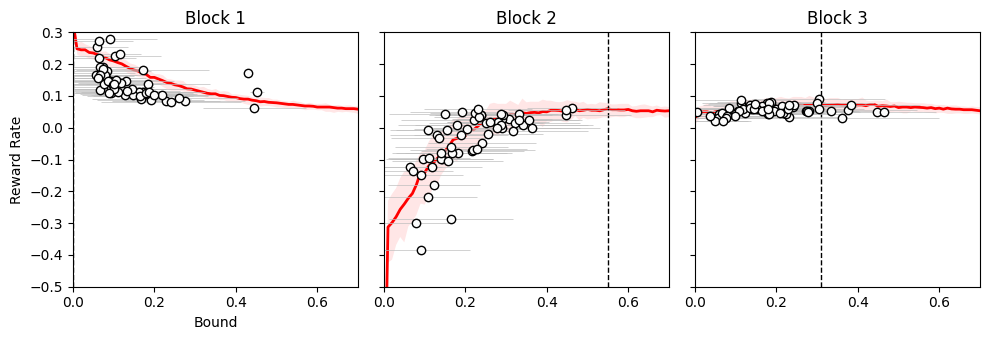

In [4]:
gr  = (0.75, 0.75, 0.75)  # gray for error bars
wt  = (0.99, 0.99, 0.99)  # near-white marker fill
rp  = (1.0,  0.9,  0.9)   # light pink for simulation ribbon

# Simulation parameters (matching MATLAB Figure04 defaults)
SIM_BOUNDS     = np.arange(0, 0.76, 0.01)   # 0 : 0.01 : 0.75
GENERATIVE_MEAN = 0.05                        # snrIndex=1, generativeMeans=[0.05 0.15]
NUM_SIM_SUBJ   = 100
rng = np.random.default_rng(0)               # fixed seed for reproducibility

fig, axs = plt.subplots(1, 3, figsize=(10, 3.5), sharey=True)

for bi, block in enumerate(BLOCKS):
    ax = axs[bi]

    # --- Simulation ribbon ---
    sim_bound_data = np.full((len(SIM_BOUNDS), 3), np.nan)  # [5th, 50th, 95th pctile]
    for ss, bnd in enumerate(SIM_BOUNDS):
        if ss % 10 == 0:
            print(f'Block {block}: simulating bound {ss+1}/{len(SIM_BOUNDS)}')
        sim_table = get_simulated_data_table(
            specs={'num_subjects': NUM_SIM_SUBJ, 'blocks': block},
            generative_mean=GENERATIVE_MEAN,
            bound_mean=bnd,
            rng=rng,
        )
        # Total coins per simulated subject (last row's cumulative coin_count)
        sim_coins = sim_table.groupby('subject_index')['coin_count'].last().to_numpy()
        sim_bound_data[ss] = np.percentile(sim_coins, [5, 50, 95]) / 600

    # Ribbon: shaded 5–95th percentile band + median line
    ax.fill_between(SIM_BOUNDS,
                    sim_bound_data[:, 0], sim_bound_data[:, 2],
                    color=rp, linewidth=0)
    ax.plot(SIM_BOUNDS, sim_bound_data[:, 1], '-', color='r', linewidth=2)

    # Vertical line at the bound with maximum simulated median reward rate
    best_idx = np.nanargmax(sim_bound_data[:, 1])
    ax.axvline(SIM_BOUNDS[best_idx], color='k', linestyle='--', linewidth=1)

    # --- Data points ---
    mean_bound  = bound_summary[:, bi, SNR_INDEX, 0, 0]
    std_bound   = bound_summary[:, bi, SNR_INDEX, 0, 1]
    reward_rate = coin_summary[:, bi, SNR_INDEX] / 600

    valid = np.isfinite(mean_bound) & np.isfinite(reward_rate)

    # Horizontal error bars (±1 SD of bound); no vertical error bars
    ax.errorbar(mean_bound[valid], reward_rate[valid],
                xerr=std_bound[valid], fmt='none',
                ecolor=gr, elinewidth=0.5, capsize=0)
    ax.plot(mean_bound[valid], reward_rate[valid], 'ko', markerfacecolor=wt)

    ax.set_xlim(0, 0.7)
    ax.set_ylim(-0.5, 0.3)
    ax.set_title(f'Block {block}')
    if bi == 0:
        ax.set_xlabel('Bound')
        ax.set_ylabel('Reward Rate')

plt.tight_layout()
plt.show()

## Bottom row: Bound comparisons across blocks
Block 1 vs 2, and block 2 vs 3. Each point = one subject.

Block 1 vs 2: median diff=0.07 [0.03 0.13], p=0.00, Spearman r=0.40 (p=0.002)
   RR: Spearman r=-0.46 (p=0.000)
Block 2 vs 3: median diff=-0.03 [-0.06 0.02], p=0.01, Spearman r=0.60 (p=0.000)
   RR: Spearman r=0.19 (p=0.148)


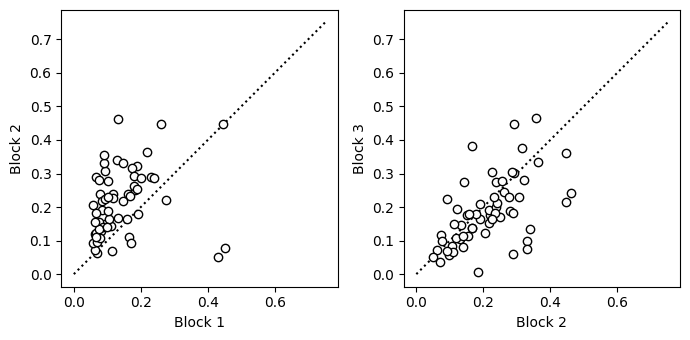

In [5]:
comparisons = [(0, 1, 1, 2), (1, 2, 2, 3)]  # (bi_x, bi_y, label_x, label_y)

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))

for ax, (bx, by, lx, ly) in zip(axs, comparisons):
    xs = bound_summary[:, bx, SNR_INDEX, 0, 0]  # mean bound, block lx
    ys = bound_summary[:, by, SNR_INDEX, 0, 0]  # mean bound, block ly

    valid = np.isfinite(xs) & np.isfinite(ys)

    # Identity line
    ax.plot([0, 0.75], [0, 0.75], 'k:')

    # One point per subject
    ax.plot(xs[valid], ys[valid], 'ko', markerfacecolor=wt)

    ax.set_xlabel(f'Block {lx}')
    ax.set_ylabel(f'Block {ly}')

    # Stats: median diff with IQR, Wilcoxon signed-rank, Spearman correlation
    diff = ys[valid] - xs[valid]
    pcts = np.percentile(diff, [25, 50, 75])
    _, p_rank = scipy.stats.wilcoxon(xs[valid], ys[valid])
    r, p_corr = scipy.stats.spearmanr(xs[valid], ys[valid])
    print(f'Block {lx} vs {ly}: median diff={pcts[1]:.2f} [{pcts[0]:.2f} {pcts[2]:.2f}], '
          f'p={p_rank:.2f}, Spearman r={r:.2f} (p={p_corr:.3f})')

    # RR correlation
    xrs = coin_summary[:, bx, SNR_INDEX][valid] / 600
    yrs = coin_summary[:, by, SNR_INDEX][valid] / 600
    rr, pr = scipy.stats.spearmanr(xrs, yrs)
    print(f'   RR: Spearman r={rr:.2f} (p={pr:.3f})')

plt.tight_layout()
plt.show()

## Formatted figure

Reproduces the 2-row × 3-column figure at publication dimensions matching MATLAB's `getPLOT_axes` call:

```matlab
getPLOT_axes(4, 17.6, [6,4], {3,3}, 1.8, 0.5, [], 'Pigeons', true)
```

- **Width**: 17.6 cm (2 JNeurosci columns)
- **Row heights**: [6, 4] cm; vertical separation 1.8 cm; horizontal 0.5 cm
- **Font size**: 12 pt
- Top row: RR vs. bound per block with simulation ribbon. Bottom row: bound comparisons (block 1 vs 2, block 2 vs 3); 6th panel left blank, matching MATLAB `set(axs(end), 'Visible', 'off')`.
- Saves to `Figure04_formatted.pdf`.

Recomputes the simulation ribbon with a fixed seed (`np.random.default_rng(0)`) for reproducibility.

In [ ]:
# ── Publication layout matching MATLAB getPLOT_axes(4, 17.6, [6,4], {3,3}, 1.8, 0.5) ──
import matplotlib.gridspec as gridspec

CM  = 1 / 2.54
WID = 17.6
HTS = [6.0, 4.0]
PSH = 1.8
PSW = 0.5
FS  = 12

fig_h       = sum(HTS) + PSH * (len(HTS) - 1)   # 11.8 cm
panel_w     = (WID - 2 * PSW) / 3               # 5.533 cm
hspace_frac = PSH / np.mean(HTS)                 # 1.8 / 5
wspace_frac = PSW / panel_w                      # 0.5 / 5.533

fig_fmt = plt.figure(figsize=(WID * CM, fig_h * CM))
gs = gridspec.GridSpec(2, 3, figure=fig_fmt,
                       height_ratios=HTS,
                       hspace=hspace_frac, wspace=wspace_frac,
                       left=0, right=1, bottom=0, top=1)

axs_top = [fig_fmt.add_subplot(gs[0, c]) for c in range(3)]
axs_bot = [fig_fmt.add_subplot(gs[1, c]) for c in range(2)]  # 3rd panel left blank

plt.rcParams.update({'font.size': FS, 'axes.labelsize': FS, 'axes.titlesize': FS})

gr_fmt = (0.75, 0.75, 0.75)
wt_fmt = (0.99, 0.99, 0.99)
rp_fmt = (1.0,  0.9,  0.9)

# ── Top row: RR vs. bound per block (recompute simulation with fixed seed) ────
rng_fmt = np.random.default_rng(0)

for bi, block in enumerate(BLOCKS):
    ax = axs_top[bi]

    # Simulation ribbon: 5th/50th/95th percentile of reward rate vs. bound
    sbd = np.full((len(SIM_BOUNDS), 3), np.nan)
    for ss, bnd in enumerate(SIM_BOUNDS):
        sim_table = get_simulated_data_table(
            specs={'num_subjects': NUM_SIM_SUBJ, 'blocks': block},
            generative_mean=GENERATIVE_MEAN,
            bound_mean=bnd,
            rng=rng_fmt,
        )
        sim_coins = sim_table.groupby('subject_index')['coin_count'].last().to_numpy()
        sbd[ss] = np.percentile(sim_coins, [5, 50, 95]) / 600

    ax.fill_between(SIM_BOUNDS, sbd[:, 0], sbd[:, 2], color=rp_fmt, linewidth=0)
    ax.plot(SIM_BOUNDS, sbd[:, 1], '-', color='r', linewidth=2)
    best_idx = np.nanargmax(sbd[:, 1])
    ax.axvline(SIM_BOUNDS[best_idx], color='k', linestyle='--', linewidth=1)

    # Data: mean bound ± 1 SD (horizontal error bars), reward rate on y
    mean_b   = bound_summary[:, bi, SNR_INDEX, 0, 0]
    std_b    = bound_summary[:, bi, SNR_INDEX, 0, 1]
    rr       = coin_summary[:, bi, SNR_INDEX] / 600
    valid_bi = np.isfinite(mean_b) & np.isfinite(rr)

    ax.errorbar(mean_b[valid_bi], rr[valid_bi],
                xerr=std_b[valid_bi], fmt='none',
                ecolor=gr_fmt, elinewidth=0.5, capsize=0)
    ax.plot(mean_b[valid_bi], rr[valid_bi], 'ko', markerfacecolor=wt_fmt)

    ax.set_xlim(0, 0.7)
    ax.set_ylim(-0.5, 0.3)
    ax.set_title(f'Block {block}')
    if bi == 0:
        ax.set_xlabel('Bound')
        ax.set_ylabel('Reward Rate')

# ── Bottom row: Bound comparisons across blocks ───────────────────────────────
comparisons = [(0, 1, 1, 2), (1, 2, 2, 3)]
for ax, (bx, by, lx, ly) in zip(axs_bot, comparisons):
    xs = bound_summary[:, bx, SNR_INDEX, 0, 0]
    ys = bound_summary[:, by, SNR_INDEX, 0, 0]
    valid_cc = np.isfinite(xs) & np.isfinite(ys)
    ax.plot([0, 0.75], [0, 0.75], 'k:')
    ax.plot(xs[valid_cc], ys[valid_cc], 'ko', markerfacecolor=wt_fmt)
    ax.set_xlabel(f'Block {lx}')
    ax.set_ylabel(f'Block {ly}')

for ax in axs_top + axs_bot:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

out = FIGURES_DIR / 'Figure04_formatted.pdf'
fig_fmt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out}')